# Red Team Attack Notebook  --  Operation GRIDLOCK

---

### Attack rules

You may attack **any unprotected (armored=False) link** -- source→relay, relay→relay, or relay→sink. Armored links are completely immune.

| Action | Target | Effect | Cost |
|--------|--------|--------|------|
| `sever` | unprotected link | Permanently removes it | 10u (flat) |
| `degrade` | unprotected link | Halves capacity | 5u (flat) |

Costs are **flat** -- distance doesn't matter. Longer links are more exposed, not more expensive to attack.

### Workflow
1. Set team id, budget, and target file → run **Load**
2. Study the **Target Map** -- note unprotected vs armored links
3. Read the **Impact Table** -- sorted by drop per sever cost
4. Write 2-3 **Scenarios**, choose one
5. **Budget Check** and **Dry-Run**
6. **Export** and upload

In [ ]:
from gridlock_core import *
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob, os
print('Notebook ready.')

---
## Load Target  *(edit the three variables)*

In [7]:
# ============================================================
#  EDIT THESE  (then run the cell)
# ============================================================
RED_TEAM_ID = "RT1"
MY_BUDGET   = 80
TARGET_FILE = "BT1_network.csv"

nodes_df, edges_df, meta = load_network_csv(TARGET_FILE)
BT_ID = meta.get("team_id", "?")

attackable = edges_df[~edges_df["armored"]]
protected  = edges_df[edges_df["armored"]]

print("Target:    " + BT_ID + " -- " + meta.get("team_name","?"))
print("Strategy:  " + meta.get("strategy","?"))
print("Relays:    " + str(len(nodes_df)))
print("Links:     " + str(len(edges_df))
      + "  (" + str(len(attackable)) + " unprotected, "
      + str(len(protected)) + " armored)")
print("Budget:    " + str(MY_BUDGET) + "u")


Target:    BT1 -- My Team
Strategy:  redundancy
Relays:    8
Links:     23  (19 unprotected, 4 armored)
Budget:    80u


---
## Target Network Map

Grey dashed = unprotected (attackable). Green solid = armored (immune). Width = capacity.

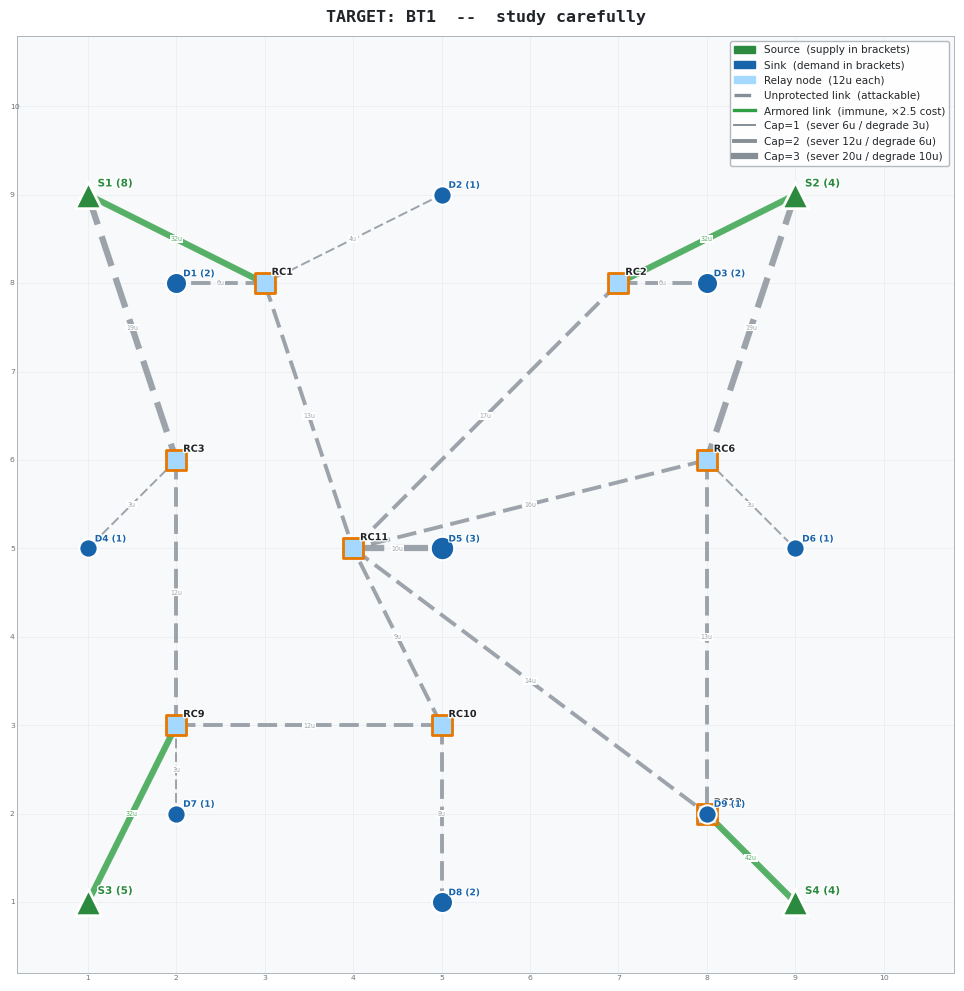

In [9]:
fig, ax = plt.subplots(figsize=(11,10), facecolor="white")
draw_network(nodes_df, edges_df, ax=ax,
             title="TARGET: " + BT_ID + "  --  study carefully",
             show_candidates=False)
plt.tight_layout()
plt.savefig("target_" + BT_ID + ".png", dpi=130,
            bbox_inches="tight", facecolor="white")
plt.show()


---
## Attack Scenarios  *(edit this cell)*

In [21]:
# ============================================================
#  ATTACK SCENARIOS  --  EDIT THIS CELL
# ============================================================
# Each step: (step_number, "edge", link_id, action, rationale)
#   action : "sever"   -- permanently removes the link (ATK_SEVER)
#             "degrade" -- halves capacity             (ATK_DEGRADE)
#
# Only unprotected (armored=False) links are valid targets.
# Look at the Impact Table to identify which links cause the most damage
# per unit of budget.
#
# Strategic tips:
#   - Any unprotected link can be severed for 10u or degraded for 5u, regardless of capacity.
#     Cutting even ONE unprotected link to a high-demand sink can be decisive.
#   - Combining degrade + sever on a bottleneck costs 5+10=15u
#     and also disrupts two steps, straining the Blue Team's resilience score.
#   - If two low-cost links lead to the same sink, severing BOTH is cheaper
#     than attacking one high-capacity link.

SCENARIOS = {
    "Plan A -- Isolate Downtown via source spines": [
        (1, "edge", "S1-RC3",  "sever",   "Cut NW cap=2 spine to RC11"),
        (2, "edge", "RC10-RC11", "sever",   "Cut S  cap=2 spine to RC11"),
        (3, "edge", "S2-RC6",    "degrade", "Weaken NE source feed"),
    ],
    "Plan B -- Degrade then sever backbone": [
        (1, "edge", "RC1-RC11",  "degrade", "Weaken NW spine (cheaper)"),
        (2, "edge", "RC10-RC11", "degrade", "Weaken S spine"),
        (3, "edge", "RC6-RC11",  "sever",   "Cut E feed to RC11"),
        (4, "edge", "RC2-RC11",  "sever",   "Fully isolate Downtown"),
    ],
    "Plan C -- Sever last-mile sink links": [
        (1, "edge", "RC11-D5",   "sever",   "Cut Downtown direct feed (cap=3)"),
        (2, "edge", "RC10-D8",   "sever",   "Cut S-Mid direct feed"),
        (3, "edge", "RC1-D1",    "sever",   "Cut N-West direct feed"),
    ],
}

CHOSEN_PLAN = "Plan A -- Isolate Downtown via source spines"

PREDICTED_MIN = 0.50

VULNERABILITY_ANALYSIS = (
    "Replace with your analysis (min 60 chars, graded). "
    "Which unprotected links have the highest drop per attack cost? "
    "What sequence isolates Downtown (demand=3) within budget?"
)


---
## Budget Check  *(auto)*

In [24]:
def _plan_cost(steps):
    em = {r.id: r for r in edges_df.itertuples()}
    total = 0
    for _s, ttype, tid, action, _r in steps:
        if ttype == "node":
            total += 999
        elif tid in em:
            total += ATK_DEGRADE if action == "degrade" else ATK_SEVER
        else:
            total += 10  # unknown -- use flat sever cost
    return total

print("My budget:", MY_BUDGET, "u")
print()
print("Plan".ljust(50) + " Cost  Left  Status")
print("-" * 65)
for name, steps in SCENARIOS.items():
    c  = _plan_cost(steps)
    r  = MY_BUDGET - c
    st = "OK" if r >= 0 else "OVER BUDGET"
    arrow = "  <- chosen" if name == CHOSEN_PLAN else ""
    print(name.ljust(50) + str(c).rjust(4) + "u"
          + str(r).rjust(5) + "u  " + st + arrow)


---
## Dry-Run Simulation  *(auto)*

In [26]:
chosen_steps = SCENARIOS[CHOSEN_PLAN]
atk_df = pd.DataFrame(chosen_steps,
    columns=["step","target_type","target_id","action","rationale"])

curve, events, dead_e, deg_e = run_attacks(nodes_df, edges_df, atk_df)

print("Plan:", CHOSEN_PLAN)
print("Intact:", str(round(curve[0]*100)) + "%")
print()
total_spent = 0
for ev in events:
    total_spent += ev["cost"]
    print("Step " + str(ev["step"]) + ": " + ev["summary"])
    iso = ("  Isolated: " + str(ev["isolated"])) if ev["isolated"] else ""
    print("  -> " + str(round(ev["frac"]*100)) + "%" + iso)
print()
print("Budget spent: " + str(total_spent) + "/" + str(MY_BUDGET) + "u")
sc = score_resilience(curve)
print("Resilience: R1=" + str(sc["R1"])
      + "  R2=" + str(sc["R2"])
      + "  Score=" + str(sc["total"]) + "/100")
print("Prediction: " + str(round(PREDICTED_MIN*100)) + "%  Actual: "
      + str(round(min(curve)*100)) + "%"
      + "  Error: " + str(round(abs(PREDICTED_MIN-min(curve))*100)) + "%")


In [28]:
fig = plt.figure(figsize=(18,9), facecolor="white")
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.06)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
draw_network(nodes_df, edges_df, ax=ax1,
             title=BT_ID + " -- post-attack state",
             dead_edges=dead_e, degraded_edges=deg_e,
             show_candidates=False)
draw_curve(curve, ax2, label="Resilience -- " + BT_ID, pred=PREDICTED_MIN)
plt.suptitle("DRY RUN  |  " + RED_TEAM_ID + " -> " + BT_ID,
             color=PAL["text"], fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RED_TEAM_ID + "_vs_" + BT_ID + "_dryrun.png",
            dpi=130, bbox_inches="tight", facecolor="white")
plt.show()


---
## Export Attack CSV  *(run last)*

In [ ]:
def _net_csv(team_id, team_name, strategy, rationale, nodes_df, edges_df):
    import pandas as pd
    cols = ["record","id","value","role","x","y","label",
            "source","target","cap","armored"]
    def m(k, v):
        row = {c:"" for c in cols}; row.update({"record":"META","id":k,"value":str(v)}); return row
    def n(r):
        row = {c:"" for c in cols}
        row.update({"record":"NODE","id":r.id,"role":r.role,
                    "x":r.x,"y":r.y,"label":r.label}); return row
    def e(r):
        row = {c:"" for c in cols}
        row.update({"record":"EDGE","id":r.id,"source":r.source,"target":r.target,
                    "cap":int(r.cap),"armored":bool(r.armored)}); return row
    rows = ([m("team_id",team_id), m("team_name",team_name),
             m("strategy",strategy),
             m("rationale",rationale.strip().replace("\n"," "))]
            + [n(r) for r in nodes_df.itertuples()]
            + [e(r) for r in edges_df.itertuples()])
    return pd.DataFrame(rows)[cols]


def _atk_csv(rt_id, bt_id, plan_name, pred_min, vuln, steps):
    import pandas as pd
    cols = ["record","step","id","value","target_type","target_id","action","rationale"]
    def m(k,v):
        row={c:"" for c in cols}; row.update({"record":"META","id":k,"value":str(v)}); return row
    def a(s,tt,tid,act,rat):
        row={c:"" for c in cols}
        row.update({"record":"ATTACK","step":s,"target_type":tt,
                    "target_id":tid,"action":act,"rationale":rat}); return row
    rows = ([m("red_team_id",rt_id), m("target_team_id",bt_id),
             m("chosen_plan",plan_name), m("predicted_min",pred_min),
             m("vuln_analysis",vuln.strip().replace("\n"," "))]
            + [a(s,tt,tid,act,rat) for s,tt,tid,act,rat in steps])
    return pd.DataFrame(rows)[cols]

df    = _atk_csv(RED_TEAM_ID, BT_ID, CHOSEN_PLAN,
                 PREDICTED_MIN, VULNERABILITY_ANALYSIS,
                 SCENARIOS[CHOSEN_PLAN])
fname = RED_TEAM_ID + "_vs_" + BT_ID + "_attacks.csv"
df.to_csv(fname, index=False)
print("Saved ->", fname)
